In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')


In [4]:
# 设置中文显示和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")


In [5]:
# 从sklearn直接加载鸢尾花数据集
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 输出改为俄语
print("Основная информация о наборе данных:")
print(f"Форма набора данных: {iris_df.shape}")
print(f"\nПервые 5 строк данных:")
print(iris_df.head())
print(f"\nСтатистическая информация о данных:")
print(iris_df.describe())
print(f"\nРаспределение классов:")
print(iris_df['species'].value_counts())


Основная информация о наборе данных:
Форма набора данных: (150, 6)

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Статистическая информация о данных:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4

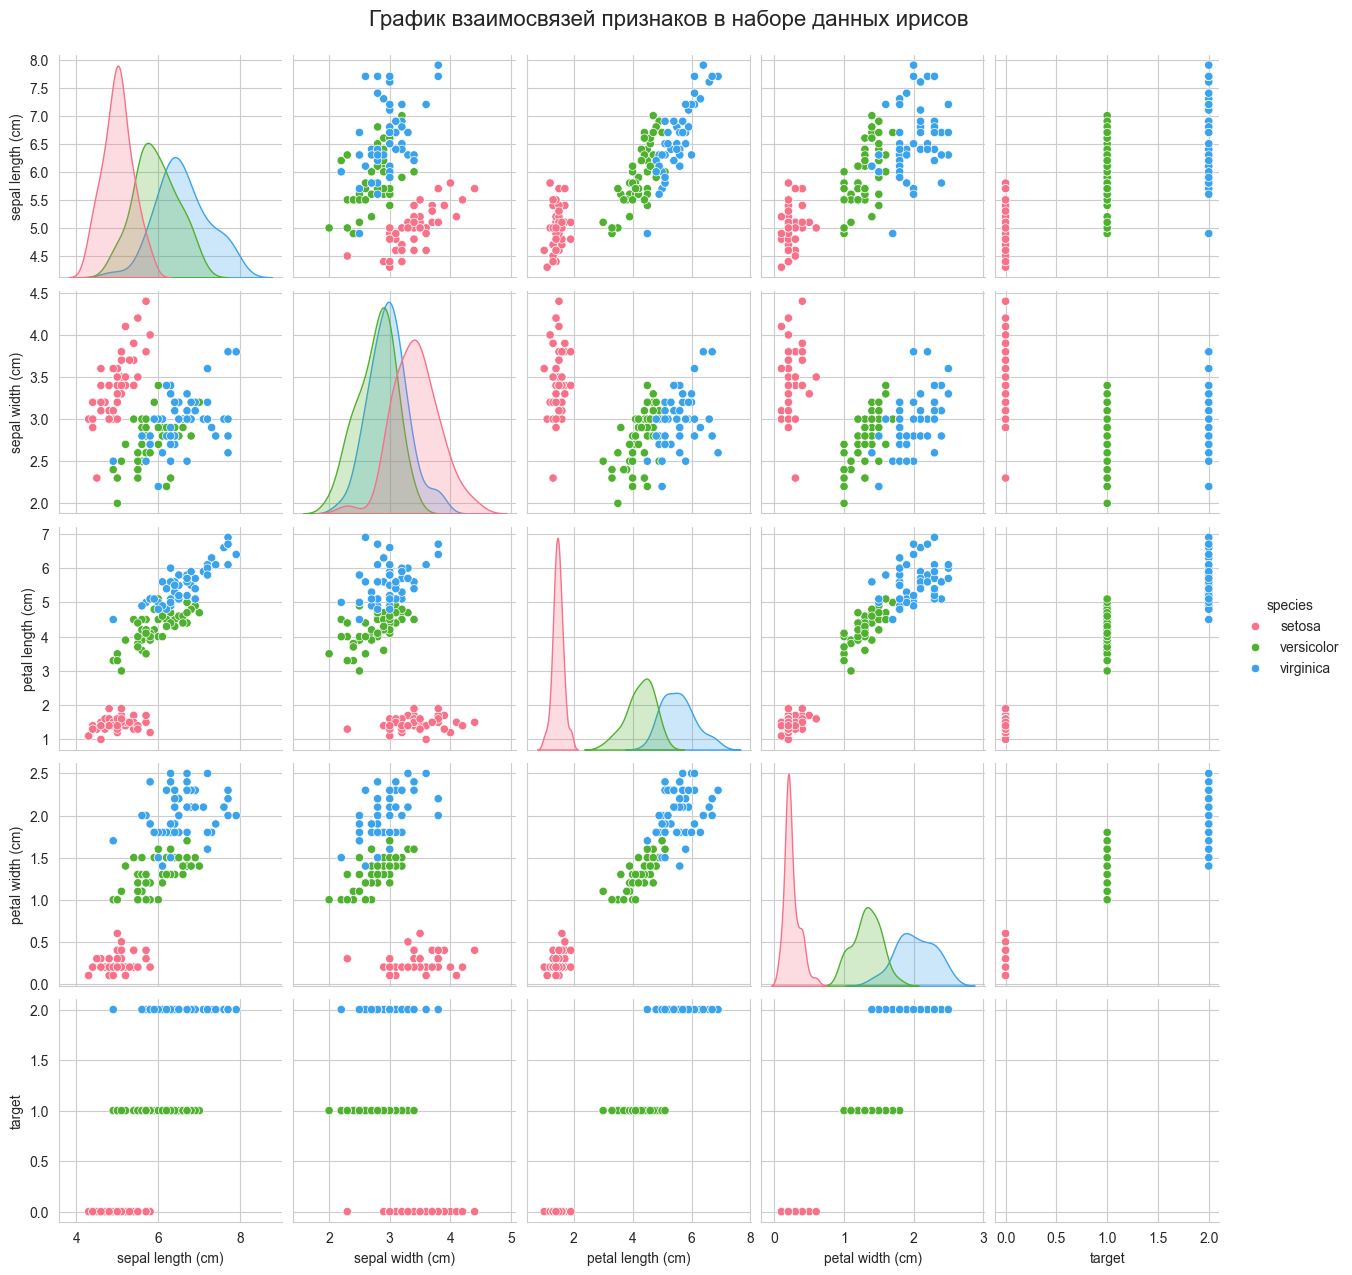

In [6]:
# # 任务2：数据可视化分析
# 使用pairplot进行数据可视化分析
sns.pairplot(iris_df, hue='species', palette='husl', diag_kind='kde')
plt.suptitle('График взаимосвязей признаков в наборе данных ирисов', y=1.02, fontsize=16)

plt.show()


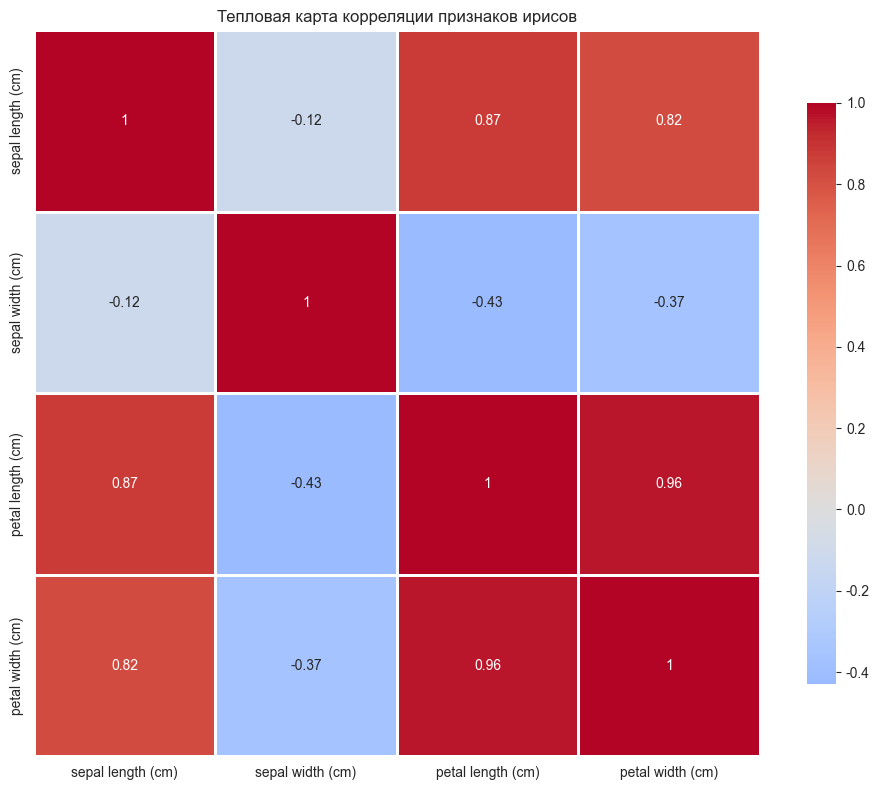

In [7]:
# 单独绘制相关性热图
plt.figure(figsize=(10, 8))
correlation_matrix = iris_df.iloc[:, :4].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляции признаков ирисов')
plt.tight_layout()
plt.show()

In [8]:
# 任务3：逻辑回归二元分类(Бинарная классификация с использованием логистической регрессии)
# 准备二元分类数据（将setosa和非setosa分开）
iris_df['binary_target'] = (iris_df['target'] == 0).astype(int)  # 0: setosa, 1: 非setosa

# 选择特征和标签
X = iris_df[['sepal length (cm)', 'sepal width (cm)',
             'petal length (cm)', 'petal width (cm)']]
y_binary = iris_df['binary_target']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print("Статистика бинарной классификации:")
print(f"Количество Setosa (класс 0): {(y_binary == 0).sum()}")
print(f"Количество не Setosa (класс 1): {(y_binary == 1).sum()}")
print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Статистика бинарной классификации:
Количество Setosa (класс 0): 100
Количество не Setosa (класс 1): 50

Размер обучающей выборки: 105
Размер тестовой выборки: 45


In [9]:
# 创建并训练逻辑回归模型
log_reg = LogisticRegression(random_state=42, max_iter=200)
log_reg.fit(X_train, y_train)

# 预测
y_pred = log_reg.predict(X_test)
y_pred_train = log_reg.predict(X_train)

# 评估模型
print("Оценка модели логистической регрессии:")
print("=" * 50)
print(f"Точность на обучающей выборке: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Точность на тестовой выборке: {accuracy_score(y_test, y_pred):.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred, target_names=['setosa', 'не setosa']))

# 查看模型系数
print("\nКоэффициенты модели:")
for feature, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Перехват: {log_reg.intercept_[0]:.4f}")


Оценка модели логистической регрессии:
Точность на обучающей выборке: 1.0000
Точность на тестовой выборке: 1.0000

Отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
   не setosa       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Коэффициенты модели:
sepal length (cm): -0.3823
sepal width (cm): 0.8281
petal length (cm): -2.1935
petal width (cm): -0.8588
Перехват: 6.2320


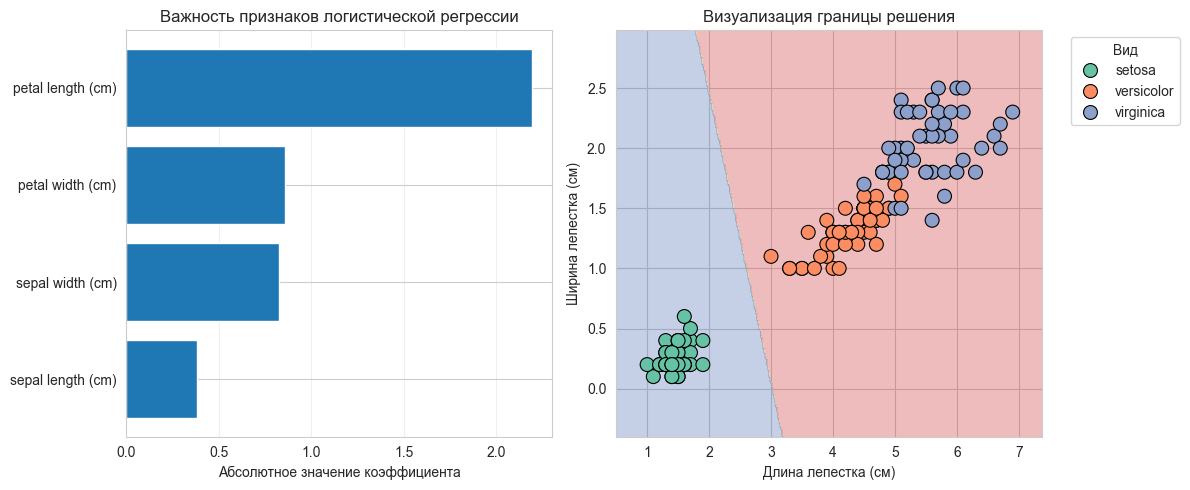

In [10]:
# 可视化二元分类结果
plt.figure(figsize=(12, 5))

# 子图1：特征重要性
plt.subplot(1, 2, 1)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': abs(log_reg.coef_[0])
}).sort_values('coefficient', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['coefficient'])
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Важность признаков логистической регрессии')
plt.grid(axis='x', alpha=0.3)

# 子图2：决策边界可视化（使用两个主要特征）
plt.subplot(1, 2, 2)
# 使用花瓣长度和花瓣宽度进行可视化
X_vis = iris_df[['petal length (cm)', 'petal width (cm)']]
y_vis = iris_df['binary_target']

# 训练一个简单的逻辑回归模型用于可视化
log_reg_simple = LogisticRegression(random_state=42)
log_reg_simple.fit(X_vis, y_vis)

# 创建网格
x_min, x_max = X_vis.iloc[:, 0].min() - 0.5, X_vis.iloc[:, 0].max() + 0.5
y_min, y_max = X_vis.iloc[:, 1].min() - 0.5, X_vis.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 预测
Z = log_reg_simple.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)',
                hue='species', palette='Set2', s=100, edgecolor='black')
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.title('Визуализация границы решения')
plt.legend(title='Вид', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [11]:
# 任务4：线性回归过拟合演示
# 生成模拟数据展示过拟合
np.random.seed(42)

# 生成数据：y = 2x + 1 + 噪声
n_samples = 30
X_simple = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = 2 * X_simple.ravel() + 1
noise = np.random.normal(0, 2, n_samples)  # 添加噪声
y_noisy = y_true + noise

print(f"Количество сгенерированных точек данных: {n_samples}")
print(f"Истинная зависимость: y = 2x + 1")


Количество сгенерированных точек данных: 30
Истинная зависимость: y = 2x + 1


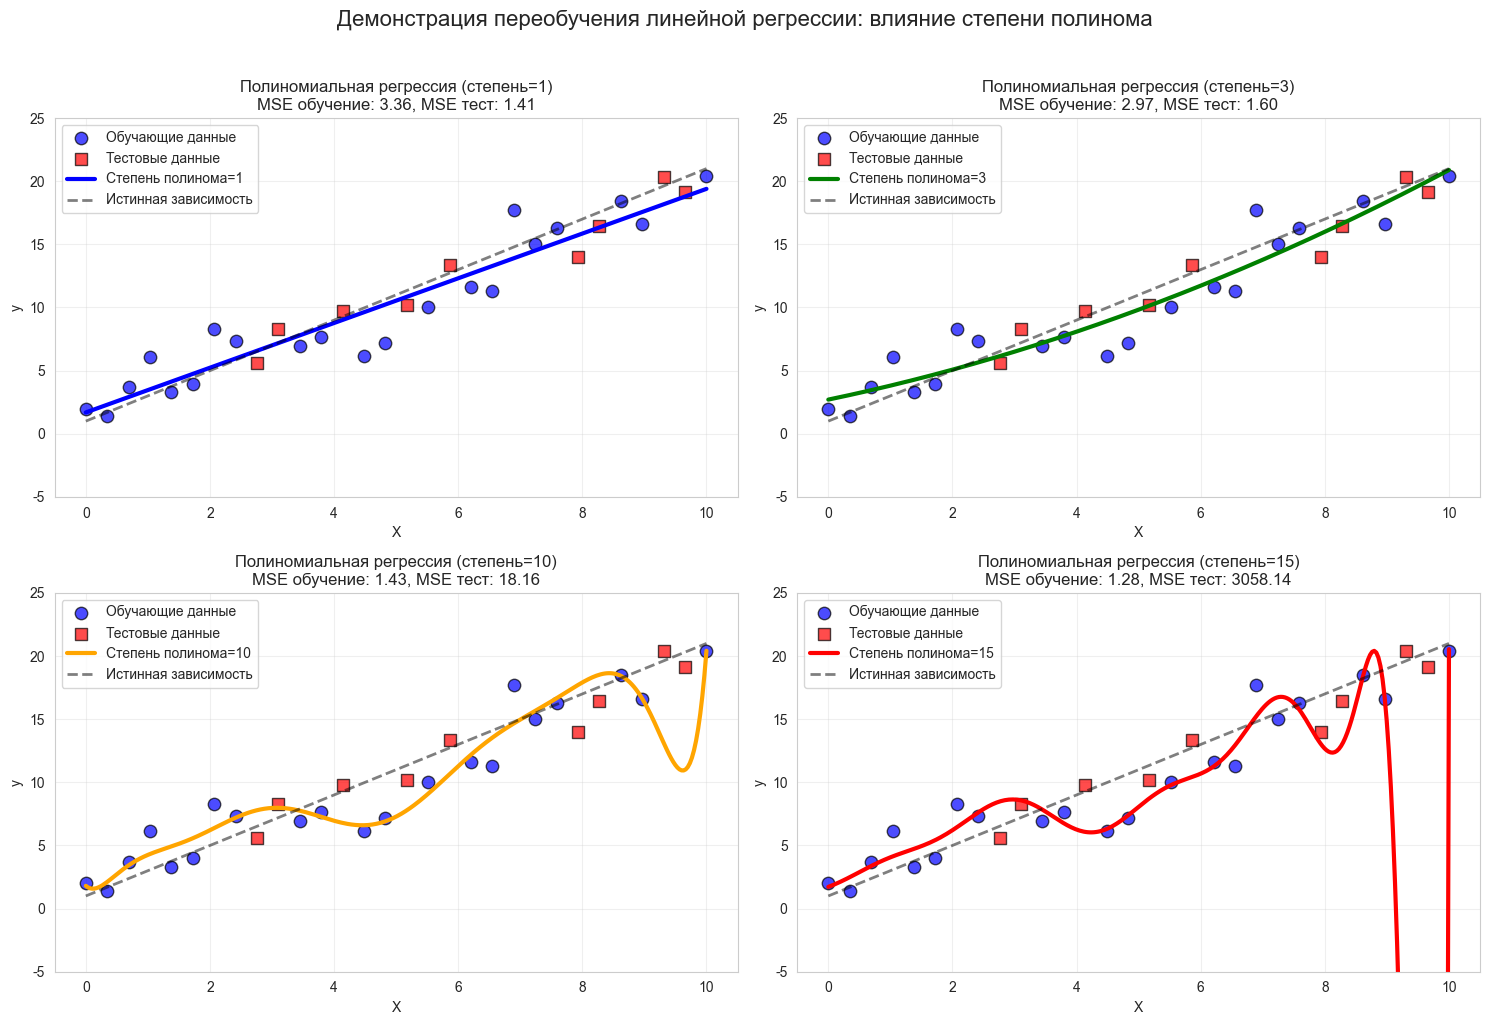

In [12]:
# 使用不同阶数的多项式回归来展示过拟合
plt.figure(figsize=(15, 10))

degrees = [1, 3, 10, 15]  # 多项式阶数
colors = ['blue', 'green', 'orange', 'red']
train_scores = []
test_scores = []

# 划分训练集和测试集
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_noisy, test_size=0.3, random_state=42
)

for idx, degree in enumerate(degrees):
    plt.subplot(2, 2, idx + 1)

    # 创建多项式回归模型
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train_simple, y_train_simple)

    # 生成平滑曲线用于可视化
    X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    # 计算训练集和测试集得分
    y_train_pred = model.predict(X_train_simple)
    y_test_pred = model.predict(X_test_simple)

    train_mse = mean_squared_error(y_train_simple, y_train_pred)
    test_mse = mean_squared_error(y_test_simple, y_test_pred)

    train_scores.append(train_mse)
    test_scores.append(test_mse)

    # 绘制图形
    plt.scatter(X_train_simple, y_train_simple, color='blue', alpha=0.7,
                label='Обучающие данные', s=80, edgecolor='black')
    plt.scatter(X_test_simple, y_test_simple, color='red', alpha=0.7,
                label='Тестовые данные', s=80, marker='s', edgecolor='black')
    plt.plot(X_plot, y_plot, color=colors[idx], linewidth=3,
             label=f'Степень полинома={degree}')
    plt.plot(X_plot, 2*X_plot.ravel() + 1, 'k--', linewidth=2, alpha=0.5,
             label='Истинная зависимость')

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Полиномиальная регрессия (степень={degree})\nMSE обучение: {train_mse:.2f}, MSE тест: {test_mse:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-5, 25)

plt.suptitle('Демонстрация переобучения линейной регрессии: влияние степени полинома', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


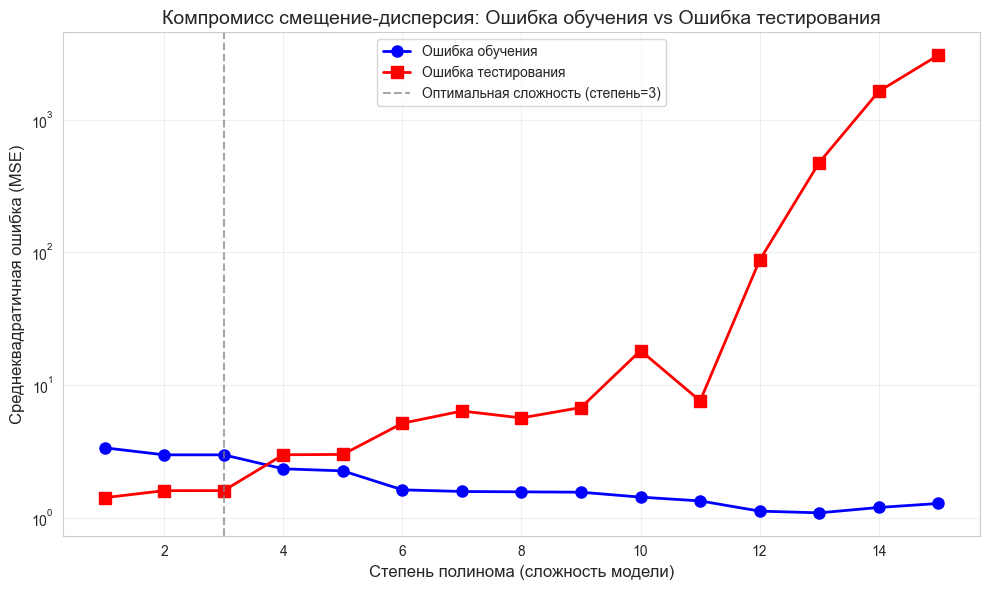

In [13]:
# 可视化训练误差和测试误差随模型复杂度的变化
plt.figure(figsize=(10, 6))
degrees_range = list(range(1, 16))
train_errors = []
test_errors = []

for degree in degrees_range:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train_simple, y_train_simple)

    y_train_pred = model.predict(X_train_simple)
    y_test_pred = model.predict(X_test_simple)

    train_errors.append(mean_squared_error(y_train_simple, y_train_pred))
    test_errors.append(mean_squared_error(y_test_simple, y_test_pred))

plt.plot(degrees_range, train_errors, 'b-o', linewidth=2, markersize=8, label='Ошибка обучения')
plt.plot(degrees_range, test_errors, 'r-s', linewidth=2, markersize=8, label='Ошибка тестирования')
plt.xlabel('Степень полинома (сложность модели)', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.title('Компромисс смещение-дисперсия: Ошибка обучения vs Ошибка тестирования', fontsize=14)
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.7, label='Оптимальная сложность (степень=3)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')  # 使用对数刻度更好显示
plt.tight_layout()
plt.show()


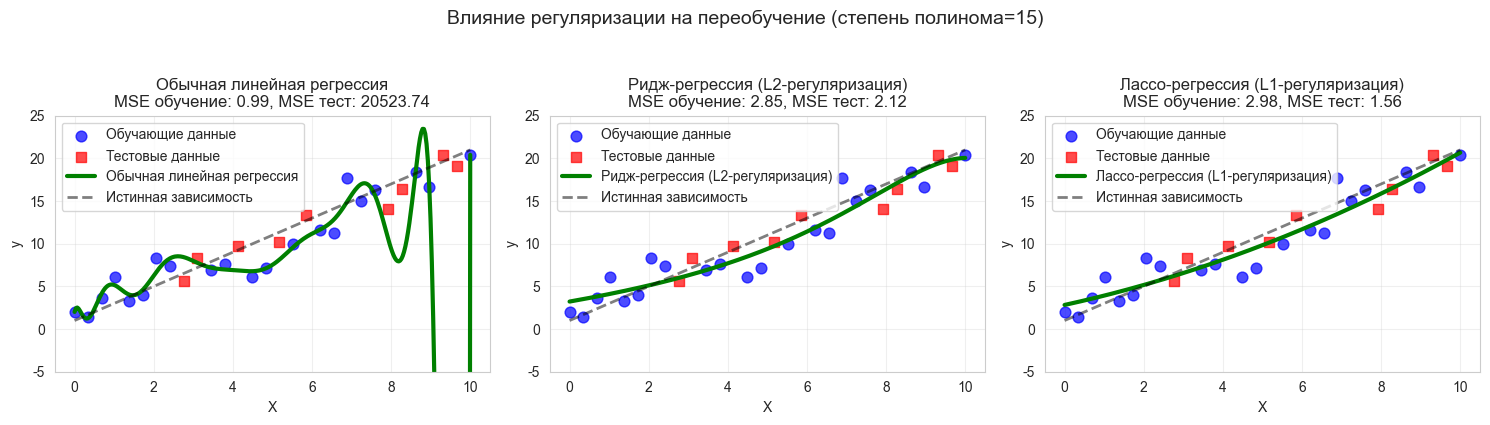

In [14]:
# 任务5：使用正则化防止过拟合
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# 使用高阶多项式特征
degree = 15
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X_simple)

# 划分数据
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_noisy, test_size=0.3, random_state=42
)

# 标准化数据
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 训练不同模型
models = {
    'Обычная линейная регрессия': LinearRegression(),
    'Ридж-регрессия (L2-регуляризация)': Ridge(alpha=1.0),
    'Лассо-регрессия (L1-регуляризация)': Lasso(alpha=0.1, max_iter=10000)
}

plt.figure(figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    plt.subplot(1, 3, idx + 1)

    # 训练模型
    model.fit(X_train_scaled, y_train_poly)

    # 生成预测
    X_plot_poly = poly.transform(np.linspace(0, 10, 300).reshape(-1, 1))
    X_plot_scaled = scaler.transform(X_plot_poly)
    y_plot = model.predict(X_plot_scaled)

    # 计算误差
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train_poly, y_train_pred)
    test_mse = mean_squared_error(y_test_poly, y_test_pred)

    # 绘制图形
    plt.scatter(X_train_simple, y_train_simple, color='blue', alpha=0.7,
                label='Обучающие данные', s=60)
    plt.scatter(X_test_simple, y_test_simple, color='red', alpha=0.7,
                label='Тестовые данные', s=60, marker='s')
    plt.plot(np.linspace(0, 10, 300), y_plot, color='green', linewidth=3,
             label=f'{name}')
    plt.plot(X_simple, y_true, 'k--', linewidth=2, alpha=0.5, label='Истинная зависимость')

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'{name}\nMSE обучение: {train_mse:.2f}, MSE тест: {test_mse:.2f}')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.ylim(-5, 25)

plt.suptitle('Влияние регуляризации на переобучение (степень полинома=15)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()
